# Regresión Lineal Simple

## Introduc

utilizo librería Scikit-Learn para implementar un modelo de regresión lineal simple que permita estimar las emisiones de CO₂ de vehículos a partir de características relacionadas con el consumo de combustible.



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np

%matplotlib inline

## Carga de Datos

Se carga el dataset FuelConsumptionCo2.csv para analizar las características de los vehículos y sus emisiones de dióxido de carbono.

In [ ]:
import os

for raiz, carpetas, archivos in os.walk("/"):
    for archivo in archivos:
        if "Fuel" in archivo:
            print(os.path.join(raiz, archivo))

/FuelConsumptionCo2.csv


In [ ]:
df = pd.read_csv("FuelConsumptionCo2.csv")

df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## 3. Exploración de los datos

Se realiza una exploración inicial para conocer la estructura y características estadísticas del conjunto de datos.

In [ ]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


## 4. Selección de variables relevantes

Para el análisis se seleccionan las variables más relacionadas con las emisiones de CO₂.

In [ ]:
cdf = df[['ENGINESIZE',
          'CYLINDERS',
          'FUELCONSUMPTION_COMB',
          'CO2EMISSIONS']]

cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


## 5. Visualización de distribuciones

Se generan histogramas para observar la distribución de las variables seleccionadas.

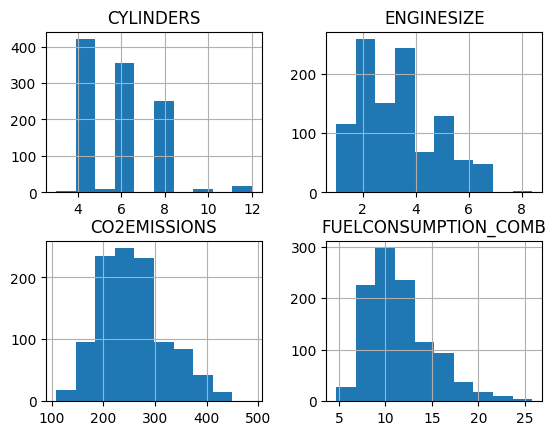

In [ ]:
viz = cdf[['CYLINDERS',
           'ENGINESIZE',
           'CO2EMISSIONS',
           'FUELCONSUMPTION_COMB']]

viz.hist()

plt.show()

## 6. Relación entre variables

Se analiza visualmente la relación entre el consumo de combustible, tamaño del motor y emisiones de CO₂.

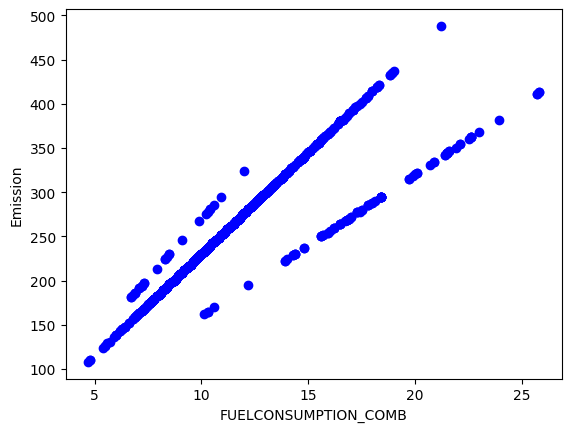

In [ ]:
plt.scatter(cdf.FUELCONSUMPTION_COMB,
            cdf.CO2EMISSIONS,
            color='blue')

plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

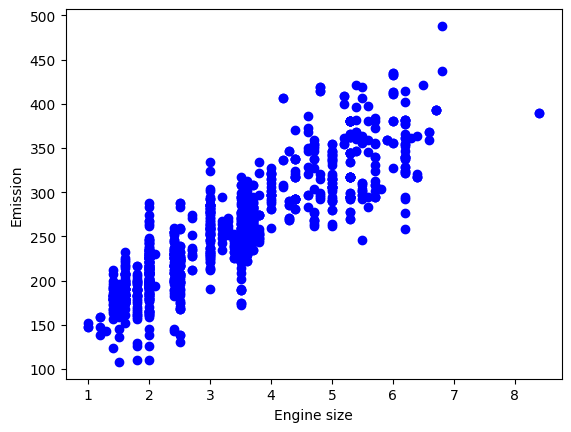

In [ ]:
plt.scatter(cdf.ENGINESIZE,
            cdf.CO2EMISSIONS,
            color='blue')

plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

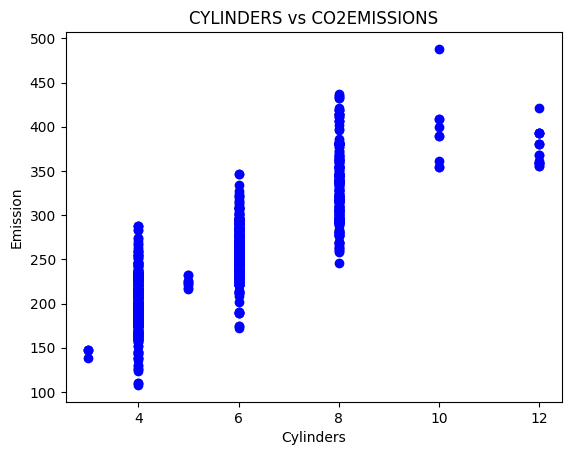

In [ ]:
plt.scatter(cdf.CYLINDERS,
            cdf.CO2EMISSIONS,
            color='blue')

plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.title("CYLINDERS vs CO2EMISSIONS")

plt.show()

Se observa una relación positiva entre la cantidad de cilindros y las emisiones de CO₂. A medida que aumenta el número de cilindros, generalmente aumentan las emisiones contaminantes del vehículo.

## 7. División del conjunto de datos

Se divide el dataset en un 80% para entrenamiento y un 20% para pruebas.

In [ ]:
msk = np.random.rand(len(df)) < 0.8

train = cdf[msk]
test = cdf[~msk]

## 8. Entrenamiento del modelo

Se utiliza la variable ENGINESIZE como variable independiente para predecir las emisiones de CO₂.

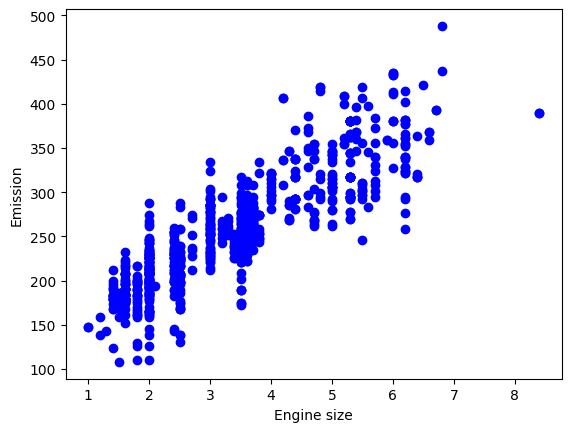

In [ ]:
plt.scatter(train.ENGINESIZE,
            train.CO2EMISSIONS,
            color='blue')

plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

In [ ]:
from sklearn import linear_model

regr = linear_model.LinearRegression()

train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

regr.fit(train_x, train_y)

print('Coeficiente:', regr.coef_)
print('Intercepto:', regr.intercept_)

Coeficiente: [[38.90855964]]
Intercepto: [125.79449382]


y = 38.90x + 125.79

In [ ]:
y = 38.90 + 125.79

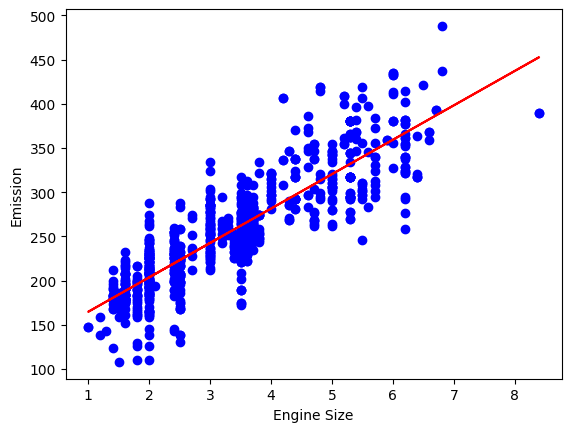

In [ ]:
plt.scatter(train.ENGINESIZE,
            train.CO2EMISSIONS,
            color='blue')

plt.plot(
    train_x,
    regr.coef_[0][0] * train_x + regr.intercept_[0],
    '-r'
)

plt.xlabel("Engine Size")
plt.ylabel("Emission")

plt.show()

## 9. Evaluación del modelo

Se utilizan diferentes métricas para medir la calidad de las predicciones realizadas por el modelo.

In [ ]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])

test_y_ = regr.predict(test_x)

print("Error medio absoluto: %.2f" %
      np.mean(np.absolute(test_y_ - test_y)))

print("MSE: %.2f" %
      np.mean((test_y_ - test_y) ** 2))

print("R2-score: %.2f" %
      r2_score(test_y, test_y_))

Error medio absoluto: 20.21
MSE: 690.69
R2-score: 0.83


## Conclusiones

El modelo logró identificar una relación lineal entre el tamaño del motor y las emisiones de CO₂.

El valor de R² obtenido indica qué tan bien el modelo explica la variabilidad de los datos. Un valor cercano a 1 representa una mejor capacidad predictiva.

Aunque el modelo presenta una precisión aceptable, existen otras variables como el consumo combinado de combustible y la cantidad de cilindros que podrían mejorar los resultados mediante una regresión múltiple.

In [ ]:
print('Coeficiente:', regr.coef_)
print('Intercepto:', regr.intercept_)

Coeficiente: [[38.90855964]]
Intercepto: [125.79449382]


## Análisis de Precisión

El modelo obtuvo un R² de 0.83, lo que indica que explica aproximadamente el 83% de la variabilidad de las emisiones de CO₂.

El Error Medio Absoluto (MAE) fue de 20.21, lo que significa que las predicciones presentan un error promedio cercano a 20 unidades respecto a los valores reales.

El Error Cuadrático Medio (MSE) fue de 690.69, mostrando un nivel aceptable de precisión para una regresión lineal simple.

En general, el modelo presenta un buen ajuste y una capacidad adecuada para estimar las emisiones de CO₂ a partir del tamaño del motor.

## Reto: Regresión Múltiple

In [ ]:
x = cdf[['ENGINESIZE',
         'CYLINDERS',
         'FUELCONSUMPTION_COMB']]

## Polinomio Generado

El modelo de regresión lineal obtuvo la siguiente ecuación:

CO2EMISSIONS = 125.79 + 38.91 × ENGINESIZE

Donde:

- 125.79 representa el intercepto del modelo.
- 38.91 representa el coeficiente asociado al tamaño del motor (ENGINESIZE).

Esto indica que, en promedio, por cada incremento de una unidad en el tamaño del motor, las emisiones de CO₂ aumentan aproximadamente 38.91 g/km.

# Reto: Regresión Múltiple y K-Fold Cross Validation

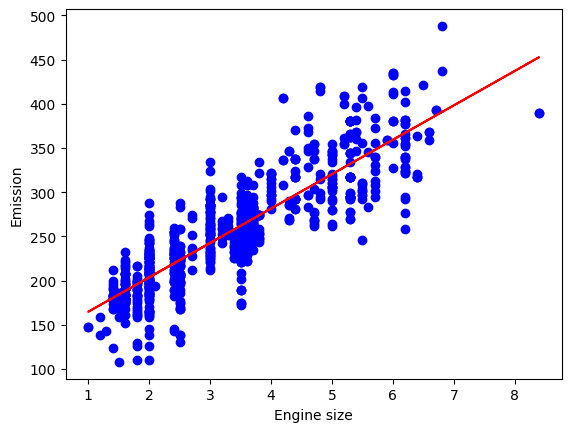

In [ ]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.plot(train_x,
         regr.coef_[0][0] * train_x + regr.intercept_[0],
         '-r')

plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

# Reto: Regresión Múltiple

In [ ]:
from sklearn import linear_model

x = cdf[['ENGINESIZE',
         'CYLINDERS',
         'FUELCONSUMPTION_COMB']]

y = cdf['CO2EMISSIONS']

regr_multi = linear_model.LinearRegression()

regr_multi.fit(x, y)

print("Coeficientes:", regr_multi.coef_)
print("Intercepto:", regr_multi.intercept_)

Coeficientes: [10.85524041  7.51622501  9.59563161]
Intercepto: 65.22328417194547


In [ ]:
ENGINESIZE             = 10.8552
CYLINDERS              = 7.5162
FUELCONSUMPTION_COMB   = 9.5956

Intercepto             = 65.2233

## Polinomio de Regresión Múltiple

El modelo obtenido es:

CO2EMISSIONS =
65.22 +
10.86 × ENGINESIZE +
7.52 × CYLINDERS +
9.60 × FUELCONSUMPTION_COMB

Donde cada coeficiente representa la contribución de la variable correspondiente en la predicción de las emisiones de CO₂.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np

X = cdf[['ENGINESIZE',
         'CYLINDERS',
         'FUELCONSUMPTION_COMB']]

Y = cdf['CO2EMISSIONS']

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

modelo = linear_model.LinearRegression()

modelo.fit(X_train, Y_train)

predicciones = modelo.predict(X_test)

print("R2:", r2_score(Y_test, predicciones))
print("MAE:", np.mean(np.abs(predicciones - Y_test)))

R2: 0.875970520691407
MAE: 16.721593983516485


## Análisis de la Regresión Múltiple

Se implementó un modelo de regresión múltiple utilizando las variables ENGINESIZE, CYLINDERS y FUELCONSUMPTION_COMB.

Los resultados obtenidos fueron:

- R² = 0.876
- MAE = 16.72

Al comparar estos resultados con la regresión lineal simple (R² = 0.83 y MAE = 20.21), se observa una mejora en la capacidad predictiva del modelo.

Esto demuestra que utilizar múltiples variables permite explicar mejor las emisiones de CO₂ que emplear únicamente el tamaño del motor.

In [1]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

X = cdf[['ENGINESIZE',
         'CYLINDERS',
         'FUELCONSUMPTION_COMB']]

y = cdf['CO2EMISSIONS']

modelo = LinearRegression()

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    modelo,
    X,
    y,
    cv=kfold,
    scoring='r2'
)

print("R2 por Fold:", scores)
print("Promedio R2:", scores.mean())

NameError: name 'cdf' is not defined

## K-Fold Cross Validation

Se aplicó validación cruzada K-Fold con 5 particiones para evaluar la estabilidad del modelo de regresión múltiple.

Resultados obtenidos:

* Fold 1: 0.876
* Fold 2: 0.860
* Fold 3: 0.877
* Fold 4: 0.851
* Fold 5: 0.845

Promedio R²: 0.862

Los resultados muestran una variación reducida entre las particiones, indicando que el modelo presenta un comportamiento consistente y una buena capacidad de generalización.

El modelo de regresión múltiple obtuvo un mejor desempeño que la regresión lineal simple, aumentando el valor de R² y reduciendo el error medio absoluto.
